In [1]:
# NotRequired 来自 Python 的 typing 模块扩展，它是 PEP 655 引入的特性
# NotRequired 从 Python 3.11 开始内置支持
from typing import TypedDict, NotRequired
from langgraph.graph import StateGraph
#如果你使用的是 Python ≤3.10，需要安装 typing_extensions：
# pip install typing_extensions
#from typing import TypedDict



#### 6.2.1.2 状态转移演示 

In [2]:

class TaskState(TypedDict):
    user_query: str #用户原始查询
    tool_result: NotRequired[str] #工具调用结果
    final_answer: NotRequired[str] #最终回答
    progress: NotRequired[int] #任务进度百分比

# ======节点函数=========
def parse_query(state: TaskState):
    print("\n====== 节点1 parse_query 输入状态 ======")
    print(state)

    query = state["user_query"]
    update = {
        "tool_result": f"已解析问题: {query}",
        "progress": 30
    }

    print("------ 节点1 更新字段 ------")
    print(update)

    return update


def call_tool(state: TaskState):
    print("\n====== 节点2 call_tool 输入状态 ======")
    print(state)

    result = f"工具搜索结果：关于『{state['user_query']}』的相关知识"
    update = {
        "tool_result": result,
        "progress": 70
    }

    print("------ 节点2 更新字段 ------")
    print(update)

    return update


def generate_answer(state: TaskState):
    print("\n====== 节点3 generate_answer 输入状态 ======")
    print(state)

    answer = f"最终回答：基于工具结果 -> {state['tool_result']}"
    update = {
        "final_answer": answer,
        "progress": 100
    }

    print("------ 节点3 更新字段 ------")
    print(update)

    return update


In [3]:

#========构建 LangGraph 工作流======
# from langgraph.graph import StateGraph

# 1. 创建图（绑定状态类型）
builder = StateGraph(TaskState)

# 2. 添加节点
builder.add_node("parse_query", parse_query)
builder.add_node("call_tool", call_tool)
builder.add_node("generate_answer", generate_answer)

# 3. 定义执行顺序（边）
builder.set_entry_point("parse_query")
builder.add_edge("parse_query", "call_tool")
builder.add_edge("call_tool", "generate_answer")

# 4. 编译图
graph = builder.compile()



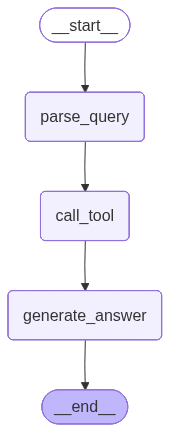

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# ====== 运行工作流 ======
init_state = TaskState(user_query="什么是 LangGraph？")

final_state = graph.invoke(init_state)

print("\n最终状态：")
print(final_state)


====== 节点1 parse_query 输入状态 ======
{'user_query': '什么是 LangGraph？'}
------ 节点1 更新字段 ------
{'tool_result': '已解析问题: 什么是 LangGraph？', 'progress': 30}

====== 节点2 call_tool 输入状态 ======
{'user_query': '什么是 LangGraph？', 'tool_result': '已解析问题: 什么是 LangGraph？', 'progress': 30}
------ 节点2 更新字段 ------
{'tool_result': '工具搜索结果：关于『什么是 LangGraph？』的相关知识', 'progress': 70}

====== 节点3 generate_answer 输入状态 ======
{'user_query': '什么是 LangGraph？', 'tool_result': '工具搜索结果：关于『什么是 LangGraph？』的相关知识', 'progress': 70}
------ 节点3 更新字段 ------
{'final_answer': '最终回答：基于工具结果 -> 工具搜索结果：关于『什么是 LangGraph？』的相关知识', 'progress': 100}

最终状态：
{'user_query': '什么是 LangGraph？', 'tool_result': '工具搜索结果：关于『什么是 LangGraph？』的相关知识', 'final_answer': '最终回答：基于工具结果 -> 工具搜索结果：关于『什么是 LangGraph？』的相关知识', 'progress': 100}


#### 6.2.2.2 节点类型

In [6]:
# from typing import TypedDict, NotRequired

class TaskState(TypedDict):
    user_query: str #用户原始查询
    intent: NotRequired[str] #用户意图
    llm_answer: NotRequired[str] #LLM 生成的回答
    tool_result: NotRequired[str] #工具调用结果
    final_answer: NotRequired[str] #最终回答
    progress: NotRequired[int] #任务进度百分比

#=======LLM 调用节点（模拟）========= 
#LLM 节点只负责“生成文本”，不负责工具、不负责格式化。
def llm_node(state: TaskState):
    print("\n🧠 [LLM Node] 输入状态:", state)

    # 模拟大模型生成
    llm_output = f"LangGraph 是一种用于构建可控AI工作流的框架，问题是：{state['user_query']}"

    return {
        "llm_answer": llm_output,
        "progress": 30
    } 

# ====== 工具调用节点（模拟检索） ======
#工具节点只做 I/O，不生成语言，不控制流程。
def tool_node(state: TaskState):
    print("\n🔧 [Tool Node] 输入状态:", state)

    # 模拟搜索工具
    tool_output = f"检索结果：LangGraph 支持 DAG、状态机、Agent workflow"

    return {
        "tool_result": tool_output,
        "progress": 70
    }

# ====== 节点3：数据处理节点 ======
#数据节点负责加工 state，而不是生成或检索。
def data_process_node(state: TaskState):
    print("\n🧹 [Data Node] 输入状态:", state)

    final = f"""
【LLM回答】{state["llm_answer"]}
【工具补充】{state["tool_result"]}
"""

    return {
        "final_answer": final.strip(),
        "progress": 100
    }
    
# from langgraph.graph import StateGraph

# 1. 创建图
builder = StateGraph(TaskState)

# 2. 添加节点
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_node("data_process_node", data_process_node)

# 3. 定义流程
builder.set_entry_point("llm_node")
builder.add_edge("llm_node", "tool_node")
builder.add_edge("tool_node", "data_process_node")

# 4. 编译
graph = builder.compile()

# 初始化状态
init_state = TaskState(user_query="什么是 LangGraph？")

# 执行
final_state = graph.invoke(init_state)

print("\n====== 最终状态 ======")
print(final_state)


🧠 [LLM Node] 输入状态: {'user_query': '什么是 LangGraph？'}

🔧 [Tool Node] 输入状态: {'user_query': '什么是 LangGraph？', 'llm_answer': 'LangGraph 是一种用于构建可控AI工作流的框架，问题是：什么是 LangGraph？', 'progress': 30}

🧹 [Data Node] 输入状态: {'user_query': '什么是 LangGraph？', 'llm_answer': 'LangGraph 是一种用于构建可控AI工作流的框架，问题是：什么是 LangGraph？', 'tool_result': '检索结果：LangGraph 支持 DAG、状态机、Agent workflow', 'progress': 70}

====== 最终状态 ======
{'user_query': '什么是 LangGraph？', 'llm_answer': 'LangGraph 是一种用于构建可控AI工作流的框架，问题是：什么是 LangGraph？', 'tool_result': '检索结果：LangGraph 支持 DAG、状态机、Agent workflow', 'final_answer': '【LLM回答】LangGraph 是一种用于构建可控AI工作流的框架，问题是：什么是 LangGraph？\n【工具补充】检索结果：LangGraph 支持 DAG、状态机、Agent workflow', 'progress': 100}


### 6.2.3 边

#### 条件边

In [7]:
def parse_intent(state: TaskState):
    print("\n🔹 parse_intent")
    # 简单模拟意图识别
    intent = "summarize" if "总结" in state['user_query'] else "rewrite"
    return {"intent": intent, "progress": 30}


def summarize_node(state: TaskState):
    print("\n🔹 summarize_node")
    return {"llm_answer": f"总结结果: {state['user_query']}", "progress": 60}


def rewrite_node(state: TaskState):
    print("\n🔹 rewrite_node")
    return {"llm_answer": f"改写结果: {state['user_query']}", "progress": 60}


def final_node(state: TaskState):
    print("\n🔹 final_node")
    return {"progress": 100}

In [8]:
def route_by_intent(state: TaskState):
    if state.get("intent") == "summarize":
        return "summarize_node"
    else:
        return "rewrite_node"


In [9]:


builder = StateGraph(TaskState)

builder.add_node("parse_intent", parse_intent)
builder.add_node("summarize_node", summarize_node)
builder.add_node("rewrite_node", rewrite_node)
builder.add_node("final_node", final_node)

builder.set_entry_point("parse_intent")

# 条件边
builder.add_conditional_edges(
    "parse_intent",
    route_by_intent,
    {
        "summarize_node": "summarize_node",
        "rewrite_node": "rewrite_node",
    }
)

builder.add_edge("summarize_node", "final_node")
builder.add_edge("rewrite_node", "final_node")

graph = builder.compile()



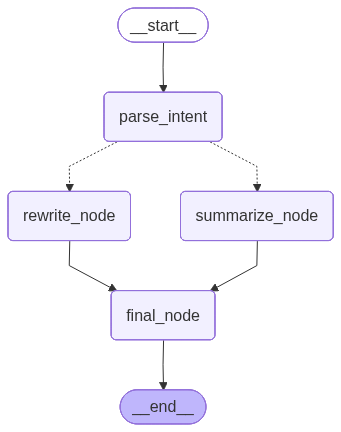

In [10]:

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:

print("\n====== 测试总结 ======")
print(graph.invoke(TaskState(user_query="请总结这段话")))

print("\n====== 测试改写 ======")
print(graph.invoke(TaskState(user_query="请改写这段话")))


====== 测试总结 ======

🔹 parse_intent

🔹 summarize_node

🔹 final_node
{'user_query': '请总结这段话', 'intent': 'summarize', 'llm_answer': '总结结果: 请总结这段话', 'progress': 100}

====== 测试改写 ======

🔹 parse_intent

🔹 rewrite_node

🔹 final_node
{'user_query': '请改写这段话', 'intent': 'rewrite', 'llm_answer': '改写结果: 请改写这段话', 'progress': 100}


#### 循环边

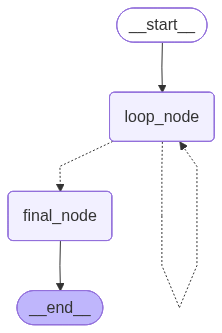

In [12]:
#=======循环节点======
def loop_node(state: TaskState):
    progress = state.get("progress", 0)
    print("\n🔄 loop_node, progress =", progress)
    return {"progress": progress + 30}

#=======循环条件函数======
def loop_router(state: TaskState):
    if state["progress"] >= 100:
        return "final_node"
    return "loop_node"

#=======构建图=========
builder = StateGraph(TaskState)

builder.add_node("loop_node", loop_node)
builder.add_node("final_node", final_node)

builder.set_entry_point("loop_node")

builder.add_conditional_edges(
    "loop_node",
    loop_router,
    {
        "loop_node": "loop_node",     # 回环
        "final_node": "final_node"    # 终止
    }
)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [13]:
print(graph.invoke(TaskState(user_query="test")))


🔄 loop_node, progress = 0

🔄 loop_node, progress = 30

🔄 loop_node, progress = 60

🔄 loop_node, progress = 90

🔹 final_node
{'user_query': 'test', 'progress': 100}


## 并行

In [14]:
from langgraph.graph import  START, END
# from typing import Optional
# from typing import TypedDict, Optional, NotRequired
import time
import random

# ===== 1. 定义状态（共享黑板） =====

class TextProcessState(TypedDict):
    raw_text: str
    summary_text: NotRequired[str]
    keyword_text: NotRequired[str]
    has_sensitive: NotRequired[bool]
    final_text: NotRequired[str]

# ===== 2. 去重节点（入口节点） =====
def deduplicate_node(state: TextProcessState):
    print("\n【节点 deduplicate】执行中...")
    text = state["raw_text"]   # ✅ TypedDict 访问方式
    time.sleep(1)
    return {"raw_text": text}

# ===== 3. 摘要节点（并行节点1） =====
def summary_node(state: TextProcessState):
    print("⚡ 并行节点 summary 执行中...")
    time.sleep(random.uniform(1, 2))
    summary = "摘要：" + state["raw_text"][:10]
    return {"summary_text": summary}

# ===== 4. 关键词节点（并行节点2） =====
def keyword_node(state: TextProcessState):
    print("⚡ 并行节点 keyword 执行中...")
    time.sleep(random.uniform(1, 2))
    keywords = "、".join(state["raw_text"].split("，")[:3])
    return {"keyword_text": keywords}

# ===== 5. 并行汇合节点 =====
def sensitive_check_node(state: TextProcessState):
    print("\n【节点 sensitive_check】汇总并行结果")
    print(" summary_text =", state["summary_text"])
    print(" keyword_text =", state["keyword_text"])

    sensitive = "暴力" in state["raw_text"]
    return {
        "has_sensitive": sensitive,
        "final_text": f"最终输出 | 摘要={state['summary_text']} | 关键词={state['keyword_text']}"
    }


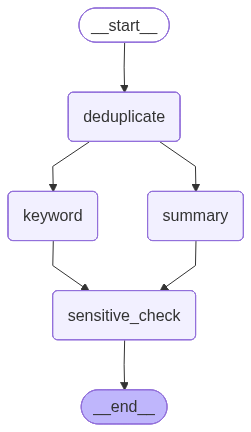

In [15]:

# ===== 6. 构建 LangGraph =====
builder = StateGraph(TextProcessState)

builder.add_node("deduplicate", deduplicate_node)
builder.add_node("summary", summary_node)
builder.add_node("keyword", keyword_node)
builder.add_node("sensitive_check", sensitive_check_node)

builder.add_edge(START, "deduplicate")

# 并行分叉
builder.add_edge("deduplicate", "summary")
builder.add_edge("deduplicate", "keyword")

# 并行汇合
builder.add_edge("summary", "sensitive_check")
builder.add_edge("keyword", "sensitive_check")

builder.add_edge("sensitive_check", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:

# ===== 7. 运行 =====
if __name__ == "__main__":
    init_state = TextProcessState(
        raw_text="LangGraph很强大，支持状态管理，支持动态分支，并行执行"
    )

    final_state = graph.invoke(init_state)

    print("\n====== 最终状态 ======")
    print(final_state)


【节点 deduplicate】执行中...
⚡ 并行节点 keyword 执行中...
⚡ 并行节点 summary 执行中...

【节点 sensitive_check】汇总并行结果
 summary_text = 摘要：LangGraph很
 keyword_text = LangGraph很强大、支持状态管理、支持动态分支

====== 最终状态 ======
{'raw_text': 'LangGraph很强大，支持状态管理，支持动态分支，并行执行', 'summary_text': '摘要：LangGraph很', 'keyword_text': 'LangGraph很强大、支持状态管理、支持动态分支', 'has_sensitive': False, 'final_text': '最终输出 | 摘要=摘要：LangGraph很 | 关键词=LangGraph很强大、支持状态管理、支持动态分支'}


# 实操案例

## 线性

In [17]:
from langchain_core.prompts import PromptTemplate
from langgraph.checkpoint.memory import MemorySaver
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
# 加载环境变量
load_dotenv()

# 初始化真实 LLM
llm = ChatOpenAI(
    api_key=os.getenv("API_KEY"),
    base_url="https://api.deepseek.com",
    model="deepseek-chat",
    temperature=0.3
)

# ==========================================================
# 1. 定义 State（工作流共享状态 = Agent 内存）
# ==========================================================
class TextProcessState(TypedDict):
    """
    LangGraph 状态对象：
    用于在节点之间传递数据（类似全局共享内存）
    """
    raw_text: str                        # 输入：用户原始文本
    deduplicated_text: NotRequired[str]  # 过程：去重后的文本
    summary_text: NotRequired[str]       # 过程：LLM 生成摘要
    has_sensitive: NotRequired[bool]     # 过程：敏感词检测结果
    final_output: NotRequired[str]       # 输出：最终格式化结果


# ==========================================================
# 2. 定义节点函数（每个节点 = 一个处理模块）
# ==========================================================
def deduplicate_node(state: TextProcessState) -> dict:
    """文本去重节点"""
    raw_text = state["raw_text"]
    lines = raw_text.split("\n")
    unique_lines = []
    seen = set()
    for line in lines:
        line_stripped = line.strip()
        if line_stripped and line_stripped not in seen:
            seen.add(line_stripped)
            unique_lines.append(line)
    print("✅ 去重节点执行完成")
    return {"deduplicated_text": "\n".join(unique_lines)}

def summary_node(state: TextProcessState) -> dict:
    """摘要生成节点（调用LLM）"""
    deduplicated_text = state["deduplicated_text"]
    prompt = PromptTemplate(
        input_variables=["text"],
        template="请为以下文本生成50字以内的简洁摘要，保留核心信息：\n{text}"
    )
    chain = prompt | llm
    summary = chain.invoke({"text": deduplicated_text}).content
    print("🤖 摘要节点执行完成")
    return {"summary_text": summary}

def sensitive_check_node(state: TextProcessState) -> dict:
    """敏感词检测节点"""
    summary = state["summary_text"]
    sensitive_words = ["敏感词1", "敏感词2", "违法", "违规"]
    has_sensitive = any(word in summary for word in sensitive_words)
    print("🔍 敏感词检测完成：", has_sensitive)
    return {"has_sensitive": has_sensitive}

def output_node(state: TextProcessState) -> dict:
    """输出节点（根据敏感词结果格式化）"""
    summary = state["summary_text"]
    has_sensitive = state["has_sensitive"]
    if has_sensitive:
        final_output = "⚠️ 检测到敏感内容，无法输出摘要"
    else:
        final_output = f"""✅ 文本处理完成【摘要】
{summary}

【去重后原文】
{state['deduplicated_text']}
"""
    print("📤 输出节点执行完成")
    return {"final_output": final_output}

e:\OneDrive\Datawhale\AIagent\src\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:

# ==========================================================
# 3. 构建线性工作流图（固定边）
# ==========================================================
def build_linear_graph():
    """构建线性 LangGraph 工作流，**实际启用状态历史**"""
    graph_builder = StateGraph(TextProcessState)

    # 注册节点
    graph_builder.add_node("deduplicate", deduplicate_node)
    graph_builder.add_node("summary", summary_node)
    graph_builder.add_node("sensitive_check", sensitive_check_node)
    graph_builder.add_node("output", output_node)

    # 配置固定边（线性执行）
    graph_builder.add_edge(START, "deduplicate")
    graph_builder.add_edge("deduplicate", "summary")
    graph_builder.add_edge("summary", "sensitive_check")
    graph_builder.add_edge("sensitive_check", "output")
    graph_builder.add_edge("output", END)

    display(Image(graph.get_graph().draw_mermaid_png()))

    # 【修改核心】编译时传入MemorySaver，真正启用状态历史
    # MemorySaver：内存级检查点，适合测试/开发，重启程序后状态丢失
    return graph_builder.compile(checkpointer=MemorySaver())

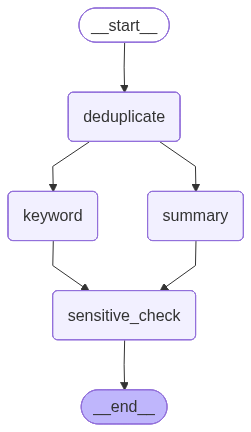

✅ 去重节点执行完成
🤖 摘要节点执行完成
🔍 敏感词检测完成： False
📤 输出节点执行完成

✅ 文本处理完成【摘要】
LangGraph是LangChain生态的工作流框架，支持状态管理、动态分支和并行执行。

【去重后原文】
LangGraph是LangChain生态的工作流框架
LangGraph支持状态管理
支持动态分支和并行执行


状态快照数量（超步骤）： 6

第1步：
state StateSnapshot(values={'raw_text': 'LangGraph是LangChain生态的工作流框架\nLangGraph支持状态管理\nLangGraph是LangChain生态的工作流框架\n支持动态分支和并行执行', 'deduplicated_text': 'LangGraph是LangChain生态的工作流框架\nLangGraph支持状态管理\n支持动态分支和并行执行', 'summary_text': 'LangGraph是LangChain生态的工作流框架，支持状态管理、动态分支和并行执行。', 'has_sensitive': False, 'final_output': '✅ 文本处理完成【摘要】\nLangGraph是LangChain生态的工作流框架，支持状态管理、动态分支和并行执行。\n\n【去重后原文】\nLangGraph是LangChain生态的工作流框架\nLangGraph支持状态管理\n支持动态分支和并行执行\n'}, next=(), config={'configurable': {'thread_id': 'text_process_test_001', 'checkpoint_ns': '', 'checkpoint_id': '1f173207-5d95-6cd5-8004-2bb6d71fc64d'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-06-28T18:37:47.852309+00:00', parent_config={'configurable': {'thread_id': 'text_process_test_001', 'checkpoint_ns': '', 'che

In [19]:

# ==========================================================
# 4. 测试运行（get_state_history 可正常使用）
# ==========================================================
if __name__ == "__main__":

    # 构建图
    linear_graph = build_linear_graph()

    # 初始状态（输入数据）
    test_state: TextProcessState = {
        "raw_text": "LangGraph是LangChain生态的工作流框架\nLangGraph支持状态管理\nLangGraph是LangChain生态的工作流框架\n支持动态分支和并行执行"
    }

    # thread_id：会话唯一标识，测试用随便命名，多会话用不同id即可
    config = {"configurable": {"thread_id": "text_process_test_001"}}

    # ========== 关键修改2：invoke时传入config ==========
    final_state = linear_graph.invoke(test_state, config=config)

    # 输出最终结果
    print("\n" + "=" * 50)
    print(final_state["final_output"])

    # ========== 关键修改3：get_state_history时也传入同一个config ==========
    print("\n" + "=" * 50)
    history = list(linear_graph.get_state_history(config))   # 必须传config
    print("状态快照数量（超步骤）：", len(history))

    for i, state in enumerate(history, 1):
        print(f"\n第{i}步：")
        print("state", state)

### 分支工作流

In [27]:
# ================== 依赖 ==================
# from typing import TypedDict, NotRequired
# from langgraph.graph import StateGraph, START, END
# from langchain_core.prompts import PromptTemplate
# from langgraph.checkpoint.memory import MemorySaver
# import os
# from dotenv import load_dotenv
# from langchain_openai import ChatOpenAI

# ================== LLM 初始化 ==================
# load_dotenv()

# llm = ChatOpenAI(
#     api_key=os.getenv("API_KEY"),
#     base_url="https://api.deepseek.com",
#     model="deepseek-chat",
#     temperature=0.3
# )

# ==========================================================
# 6.4.3 分支工作流案例：带结果校验的动态文本处理
# ==========================================================

# ----------------------------------------------------------
# 1️⃣ 状态定义：扩展工作流状态（新增循环控制字段）
# ----------------------------------------------------------
class BranchTextProcessState(TypedDict):
    """分支工作流共享状态（类似共享黑板）"""

    # 输入字段
    raw_text: str

    # 中间过程字段（可选）
    deduplicated_text: NotRequired[str]
    summary_text: NotRequired[str]
    has_sensitive: NotRequired[bool]

    # 循环控制字段
    rewrite_count: NotRequired[int]      # 重生成次数
    quality_valid: NotRequired[bool]     # 摘要质量是否合格

    # 最终输出
    final_output: NotRequired[str]


# ----------------------------------------------------------
# 2️⃣ 节点定义（工作流执行单元）
# ----------------------------------------------------------

# === 文本去重节点 ===
def deduplicate_node(state: BranchTextProcessState):
    raw_text = state["raw_text"]
    lines = raw_text.split("\n")
    seen, unique_lines = set(), []

    for line in lines:
        line = line.strip()
        if line and line not in seen:
            seen.add(line)
            unique_lines.append(line)

    print("✅ [Node] 去重完成")
    return {"deduplicated_text": "\n".join(unique_lines)}


# === 摘要生成节点 ===
def summary_node(state: BranchTextProcessState):
    text = state.get("deduplicated_text", "")
    if not text:
        return {"summary_text": "无有效文本"}

    prompt = PromptTemplate(
        input_variables=["text"],
        template="请为以下文本生成50字以内摘要，保留核心信息：\n{text}"
    )
    summary = (prompt | llm).invoke({"text": text}).content

    print("🤖 [Node] 摘要生成:", summary)
    return {"summary_text": summary}


# === 敏感词检测节点 ===
def sensitive_check_node(state: BranchTextProcessState):
    summary = state.get("summary_text", "")
    sensitive_words = ["违法", "违规"]
    has_sensitive = any(w in summary for w in sensitive_words)

    print(f"🔍 [Node] 敏感词检测: {has_sensitive}")
    return {"has_sensitive": has_sensitive}


# === 摘要质量校验节点（教学重点） ===
def quality_check_node(state: BranchTextProcessState):
    summary = state.get("summary_text", "")

    # 长度校验
    length_valid = 15 <= len(summary) <= 50

    # 信息完整性校验
    core_keywords = ["LangGraph", "工作流"]
    info_valid = all(k in summary for k in core_keywords)

    quality_valid = length_valid and info_valid
    print(f"📏 [Node] 质量校验 | 长度OK={length_valid} | 关键词OK={info_valid} | 合格={quality_valid}")

    return {"quality_valid": quality_valid}


# === 重生成次数更新节点 === # 为什么不是放在生成节点中一起？
def update_rewrite_count_node(state: BranchTextProcessState):
    count = state.get("rewrite_count", 0) + 1
    print(f"🔢 [Node] 重生成次数 -> {count}")
    return {"rewrite_count": count}


# ----------------------------------------------------------
# 3️⃣ Router：条件分支决策（LangGraph 核心）
# ----------------------------------------------------------
def rewrite_router(state: BranchTextProcessState):
    quality = state.get("quality_valid", False)
    count = state.get("rewrite_count", 0)

    print(f"🚦 [Router] quality={quality}, rewrite_count={count}")

    # 质量合格 → 输出
    if quality:
        return "to_output"

    # 不合格且次数 < 2 → 重生成
    if count < 2:
        return "to_rewrite"

    # 次数耗尽 → 强制输出
    return "to_force_output"


# ----------------------------------------------------------
# 4️⃣ 输出节点
# ----------------------------------------------------------

# 正常输出
def output_node(state: BranchTextProcessState):
    summary = state.get("summary_text", "")
    has_sensitive = state.get("has_sensitive", False)

    if has_sensitive:
        final_output = "⚠️ 检测到敏感内容，禁止输出摘要"
    else:
        final_output = f"""
✅ 文本处理完成
重生成次数: {state.get('rewrite_count', 0)}

【摘要】
{summary}

【去重原文】
{state.get('deduplicated_text')}
"""

    print("📤 [Node] 正常输出")
    return {"final_output": final_output}


# 强制输出
def force_output_node(state: BranchTextProcessState):
    summary = state.get("summary_text", "")
    final_output = f"""
⚠️ 摘要多次重生成仍不合格（教学示例）
重生成次数: {state.get('rewrite_count', 0)}
摘要长度: {len(summary)}

强制输出摘要：
{summary}
"""
    print("📤 [Node] 强制输出")
    return {"final_output": final_output}



In [30]:

# ----------------------------------------------------------
# 5️⃣ 构建 LangGraph 分支工作流
# ----------------------------------------------------------
def build_branch_graph():
    graph = StateGraph(BranchTextProcessState)

    # 注册节点
    graph.add_node("deduplicate", deduplicate_node)
    graph.add_node("summary", summary_node)
    graph.add_node("sensitive_check", sensitive_check_node)
    graph.add_node("quality_check", quality_check_node)
    graph.add_node("update_rewrite_count", update_rewrite_count_node)
    graph.add_node("output", output_node)
    graph.add_node("force_output", force_output_node)

    # 固定执行路径
    graph.add_edge(START, "deduplicate")
    graph.add_edge("deduplicate", "summary")
    graph.add_edge("summary", "sensitive_check")
    graph.add_edge("sensitive_check", "quality_check")

    # 条件分支（教学核心）
    graph.add_conditional_edges(
        "quality_check",
        rewrite_router,
        {
            "to_output": "output",
            "to_rewrite": "update_rewrite_count",
            "to_force_output": "force_output",
        }
    )

    # 循环回退路径
    graph.add_edge("update_rewrite_count", "summary")

    # 结束节点
    graph.add_edge("output", END)
    graph.add_edge("force_output", END)

    
    # display(Image(graph.get_graph().draw_mermaid_png()))

    return graph.compile(checkpointer=MemorySaver())


In [31]:


# ----------------------------------------------------------
# 6️⃣ 运行测试（课堂演示用）
# ----------------------------------------------------------
if __name__ == "__main__":
    branch_graph = build_branch_graph()

    # 初始状态
    test_state: BranchTextProcessState = {
        "raw_text": "LangGraph是LangChain生态下的有状态工作流框架，支持图结构建模、状态追溯、动态分支和并行执行，适用于复杂AI任务编排",
        "rewrite_count": 0,
    }

    config = {"configurable": {"thread_id": "branch_workflow_demo"}}

    print("\n🚀 启动分支工作流示例\n" + "=" * 60)
    final_state = branch_graph.invoke(test_state, config=config)

    # 输出结果
    print("\n🎯 最终结果:")
    print(final_state["final_output"])

    print("\n📊 执行统计:")
    print("重生成次数:", final_state.get("rewrite_count"))
    print("质量是否合格:", final_state.get("quality_valid"))

    # 状态历史（教学亮点）
    history = list(branch_graph.get_state_history(config))
    print(f"\n📜 状态历史步数: {len(history)}")

    # 可视化图
    png_data = branch_graph.get_graph().draw_mermaid_png()
    with open("branch_workflow_graph.png", "wb") as f:
        f.write(png_data)
    print("📊 工作流图已保存: branch_workflow_graph.png")


🚀 启动分支工作流示例
✅ [Node] 去重完成
🤖 [Node] 摘要生成: LangGraph是LangChain生态的有状态工作流框架，支持图建模、状态追溯、动态分支与并行执行，适用于复杂AI任务编排。
🔍 [Node] 敏感词检测: False
📏 [Node] 质量校验 | 长度OK=False | 关键词OK=True | 合格=False
🚦 [Router] quality=False, rewrite_count=0
🔢 [Node] 重生成次数 -> 1
🤖 [Node] 摘要生成: LangGraph是LangChain生态的有状态工作流框架，支持图建模、状态追溯、动态分支与并行执行，适用于复杂AI任务编排。
🔍 [Node] 敏感词检测: False
📏 [Node] 质量校验 | 长度OK=False | 关键词OK=True | 合格=False
🚦 [Router] quality=False, rewrite_count=1
🔢 [Node] 重生成次数 -> 2
🤖 [Node] 摘要生成: LangGraph是LangChain生态的有状态工作流框架，支持图建模、状态追溯、动态分支与并行执行，适用于复杂AI任务编排。
🔍 [Node] 敏感词检测: False
📏 [Node] 质量校验 | 长度OK=False | 关键词OK=True | 合格=False
🚦 [Router] quality=False, rewrite_count=2
📤 [Node] 强制输出

🎯 最终结果:

⚠️ 摘要多次重生成仍不合格（教学示例）
重生成次数: 2
摘要长度: 64

强制输出摘要：
LangGraph是LangChain生态的有状态工作流框架，支持图建模、状态追溯、动态分支与并行执行，适用于复杂AI任务编排。


📊 执行统计:
重生成次数: 2
质量是否合格: False

📜 状态历史步数: 15
📊 工作流图已保存: branch_workflow_graph.png


### 循环

In [32]:

# import os
from typing import TypedDict, Optional
# from dotenv import load_dotenv
# from langgraph.graph import StateGraph, START, END
# from langchain_core.prompts import PromptTemplate
# from langchain_openai import ChatOpenAI
# from langgraph.checkpoint.memory import MemorySaver
# ------------------------------
# 1. 环境加载与模型初始化（保留你的DeepSeek配置，无任何修改）
# ------------------------------
# load_dotenv()  # 加载.env中的API_KEY

# llm = ChatOpenAI(
#     api_key=os.getenv("API_KEY"),
#     base_url="https://api.deepseek.com",
#     model="deepseek-chat",
#     temperature=0.3
# )

# ------------------------------
# 2. 定义交互式状态（强类型，持久化存储所有流程数据）
# ------------------------------
class InteractiveOptState(TypedDict):
    user_input: str                # 固定：用户原始输入（全程不变）
    optimized_text: Optional[str]  # 动态：AI优化后文本（多轮更新）
    optimize_suggest: Optional[str]# 动态：优化建议/理由（多轮更新）
    user_feedback: Optional[str]   # 动态：用户反馈（确认/修改/退出）
    final_result: Optional[str]    # 最终：流程结束结果

# ------------------------------
# 3. 核心节点函数（无任何修改，保留你的原代码）
# ------------------------------
def optimize_node(state: InteractiveOptState) -> InteractiveOptState:
    """【机器节点】文本优化核心节点，使用管道符调用LLM"""
    user_input = state["user_input"]
    user_feedback = state["user_feedback"]

    if not user_feedback:
        prompt = PromptTemplate(
            input_variables=["text"],
            template="请优化以下文本，提升流畅度和专业度，严格保留核心信息：\n{text}\n优化完成后，单独一行以【优化理由：】开头给出1-2条简洁优化原因"
        )
        chain = prompt | llm
        result = chain.invoke({"text": user_input}).content
    else:
        prompt = PromptTemplate(
            input_variables=["text", "feedback"],
            template="根据用户反馈针对性优化文本，严格保留核心信息：\n原文本：{text}\n用户反馈：{feedback}\n优化完成后，单独一行以【优化理由：】开头给出1-2条简洁优化原因"
        )
        chain = prompt | llm
        result = chain.invoke({"text": user_input, "feedback": user_feedback}).content

    split_flag = "【优化理由：】"
    if split_flag in result:
        optimized_text, optimize_suggest = result.split(split_flag, 1)
    else:
        optimized_text = result
        optimize_suggest = "AI未生成明确优化理由，建议重新优化"

    return {
        "optimized_text": optimized_text.strip(),
        "optimize_suggest": optimize_suggest.strip()
    }

def feedback_node(state: InteractiveOptState) -> InteractiveOptState:
    """【人机交互节点】展示结果+接收用户反馈，流程中断核心"""
    print("\n" + "-"*60)
    print("📝 AI优化后文本：")
    print(state["optimized_text"])
    print("\n💡 优化建议/理由：")
    print(state["optimize_suggest"])
    print("\n" + "-"*60)

    while True:
        user_feedback = input("请输入反馈（仅需输入：确认/修改/退出）：").strip()
        if user_feedback in ["确认", "修改", "退出"]:
            break
        print("❌ 输入无效！请严格输入「确认」「修改」「退出」，无其他字符\n")
    return {"user_feedback": user_feedback}

def feedback_router(state: InteractiveOptState) -> str:
    """【条件路由节点】循环核心，直接返回目标节点名（最新API要求）"""
    feedback = state["user_feedback"]
    if feedback == "确认":
        return "final"    # 确认→final节点
    elif feedback == "修改":
        return "optimize" # 修改→optimize节点（循环核心）
    else:
        return "exit"     # 退出→exit节点

def final_node(state: InteractiveOptState) -> InteractiveOptState:
    """【机器节点】流程正常结束，生成格式化结果"""
    final_result = (
        "✅ 【多轮文本优化流程完成】\n"
        f"📌 最终优化文本：\n{state['optimized_text']}\n"
        f"💡 优化核心总结：\n{state['optimize_suggest']}"
    )
    return {"final_result": final_result}

def exit_node(state: InteractiveOptState) -> InteractiveOptState:
    """【机器节点】用户主动退出，生成终止提示"""
    return {"final_result": "🔚 【文本优化流程终止】\n你主动退出，本次无最终优化结果"}


In [37]:

# ------------------------------
# 4. 搭建循环交互图（无任何修改，保留你的原代码）
# ------------------------------
def build_interactive_graph():
    """构建LangGraph循环状态图，彻底适配最新API终极规范"""
    graph_builder = StateGraph(InteractiveOptState)

    # 添加节点（无修改）
    graph_builder.add_node("optimize", optimize_node)
    graph_builder.add_node("feedback", feedback_node)
    graph_builder.add_node("final", final_node)
    graph_builder.add_node("exit", exit_node)

    # 配置普通边（无修改）
    graph_builder.add_edge(START, "optimize")
    graph_builder.add_edge("optimize", "feedback")

    # 适配最新API：source + path
    graph_builder.add_conditional_edges(
        "feedback",  # 分支起始节点
        feedback_router,  # 路由函数（直接返回目标节点名）
        {
        "final": "final",
        "optimize": "optimize",
        "exit": "exit",
    } # 缺少node_mapping_dict就会导致图无法正确编译
    )

    # 配置结束边（无修改）
    graph_builder.add_edge("final", END)
    graph_builder.add_edge("exit", END)

    # 编译图：开启状态持久化（多轮交互必需）
    return graph_builder.compile(checkpointer=MemorySaver())


In [38]:

# ------------------------------
# 5. 运行交互测试（★仅修改初始输入部分★，改为用户手动输入+非空校验）
# ------------------------------
if __name__ == "__main__":
    # 构建循环图（彻底解决所有API报错）
    interactive_graph = build_interactive_graph()
    print("🔧 多轮交互式文本优化工具已启动（适配LangGraph最新API）...\n")

    # ★核心修改：用户手动输入待优化句子 + 非空校验★
    print("="*40 + " 输入待优化句子 " + "="*40)
    while True:
        user_input_text = input("请输入需要AI优化的句子：").strip()
        if user_input_text:  # 非空校验，避免用户输入空内容
            break
        print("❌ 输入不能为空，请重新输入需要优化的句子！\n")

    # 初始状态：使用用户输入的句子，其余字段保持默认
    initial_state: InteractiveOptState = {
        "user_input": user_input_text,  # 替换为用户输入的内容
        "optimized_text": None,
        "optimize_suggest": None,
        "user_feedback": None,
        "final_result": None
    }

    # 启动多轮交互流程（保留你的config配置）
    print(f"\n🚀 已接收你的句子，开始第一轮AI优化...")
    config = {"configurable": {"thread_id": "text_process_test_001"}}
    final_state = interactive_graph.invoke(initial_state, config=config)

    # 展示最终结果
    print("\n" + "="*60)
    print(final_state["final_result"])
    print("="*60)

    # 展示交互轮次（状态持久化验证）
    history = list(interactive_graph.get_state_history(config))
    interact_rounds = len(history) // 2  # 每轮=优化节点+反馈节点
    print("状态快照数量（超步骤）：", len(history))

    # 保存可视化流程图（保留你的原代码）
    png_data = interactive_graph.get_graph().draw_mermaid_png()  # 获取PNG字节流
    with open("interactive_optimize_graph.png", "wb") as file:  # wb=二进制写入
        file.write(png_data)
    print("📊 工作流可视化图已保存：interactive_optimize_graph.png\n")

🔧 多轮交互式文本优化工具已启动（适配LangGraph最新API）...

======================================== 输入待优化句子 ========================================

🚀 已接收你的句子，开始第一轮AI优化...

------------------------------------------------------------
📝 AI优化后文本：
LangGraph 是一款出色的工具，支持工作流构建，相比之前的 Chain 更易用。

💡 优化建议/理由：
1. 将口语化表达“这工具不错”改为更正式的“一款出色的工具”，提升专业度；2. 将“能做工作流”调整为“支持工作流构建”，使表述更准确流畅。

------------------------------------------------------------

✅ 【多轮文本优化流程完成】
📌 最终优化文本：
LangGraph 是一款出色的工具，支持工作流构建，相比之前的 Chain 更易用。
💡 优化核心总结：
1. 将口语化表达“这工具不错”改为更正式的“一款出色的工具”，提升专业度；2. 将“能做工作流”调整为“支持工作流构建”，使表述更准确流畅。
状态快照数量（超步骤）： 5
📊 工作流可视化图已保存：interactive_optimize_graph.png

